In [1]:
# Базовые библиотеки для воспроизводимости, анализа и удобного отображения результатов.
import random
from typing import  Dict, List

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

root= ".data/"

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME = "lyeonii/bert-tiny"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)


c:\Users\study\Documents\VUZ\DpoAI\didactic-pancake-AI-stuff\homeworks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Tokenizer loaded: lyeonii/bert-tiny
Tokenizer class: BertTokenizer
Model max length: 512


In [2]:
emotion = load_dataset('emotion',cache_dir=root)
emotion

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
emotion["train"][:3]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'label': [0, 0, 3]}

In [4]:
pd.DataFrame(emotion["train"]).isna().sum()

text     0
label    0
dtype: int64

In [5]:
label_names = set(emotion["train"]["label"])
label_names

{0, 1, 2, 3, 4, 5}

In [6]:
def tokenize(x,y,tokenizer=tokenizer):
    ids = []
    tokenized = []
    for i in x:
        tokenized.append(tokenizer.tokenize(i))
        ids.append(tokenizer.encode(i))
    return tokenized , ids, y

In [7]:
tokens ,token_ids, labels = tokenize(emotion["test"]['text'],emotion["test"]['label'])
print(*tokens[:5],sep="\n")

['im', 'feeling', 'rather', 'rotten', 'so', 'im', 'not', 'very', 'ambitious', 'right', 'now']
['im', 'up', '##dating', 'my', 'blog', 'because', 'i', 'feel', 'shitty']
['i', 'never', 'make', 'her', 'separate', 'from', 'me', 'because', 'i', 'don', 't', 'ever', 'want', 'her', 'to', 'feel', 'like', 'i', 'm', 'ashamed', 'with', 'her']
['i', 'left', 'with', 'my', 'bouquet', 'of', 'red', 'and', 'yellow', 'tu', '##lip', '##s', 'under', 'my', 'arm', 'feeling', 'slightly', 'more', 'optimistic', 'than', 'when', 'i', 'arrived']
['i', 'was', 'feeling', 'a', 'little', 'vain', 'when', 'i', 'did', 'this', 'one']


In [8]:
print(*token_ids[:5],sep="\n")

[101, 10047, 3110, 2738, 11083, 2061, 10047, 2025, 2200, 12479, 2157, 2085, 102]
[101, 10047, 2039, 16616, 2026, 9927, 2138, 1045, 2514, 28543, 102]
[101, 1045, 2196, 2191, 2014, 3584, 2013, 2033, 2138, 1045, 2123, 1056, 2412, 2215, 2014, 2000, 2514, 2066, 1045, 1049, 14984, 2007, 2014, 102]
[101, 1045, 2187, 2007, 2026, 26700, 1997, 2417, 1998, 3756, 10722, 15000, 2015, 2104, 2026, 2849, 3110, 3621, 2062, 21931, 2084, 2043, 1045, 3369, 102]
[101, 1045, 2001, 3110, 1037, 2210, 15784, 2043, 1045, 2106, 2023, 2028, 102]


In [9]:
special_tokens_df = pd.DataFrame(
    {
        "name": [
            "cls_token",
            "sep_token",
            "pad_token",
            "unk_token",
            "mask_token",
        ],
        "token": [
            tokenizer.cls_token,
            tokenizer.sep_token,
            tokenizer.pad_token,
            tokenizer.unk_token,
            tokenizer.mask_token,
        ],
        "token_id": [
            tokenizer.cls_token_id,
            tokenizer.sep_token_id,
            tokenizer.pad_token_id,
            tokenizer.unk_token_id,
            tokenizer.mask_token_id,
        ],
    }
)
print(special_tokens_df)

         name   token  token_id
0   cls_token   [CLS]       101
1   sep_token   [SEP]       102
2   pad_token   [PAD]         0
3   unk_token   [UNK]       100
4  mask_token  [MASK]       103


In [10]:
t=tokenizer(
    list(emotion["test"]['text'][:5]),
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    padding=True,
    max_length=12
)
t

c:\Users\study\Documents\VUZ\DpoAI\didactic-pancake-AI-stuff\homeworks\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:2333: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


{'input_ids': [[101, 10047, 3110, 2738, 11083, 2061, 10047, 2025, 2200, 12479, 2157, 2085, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 10047, 2039, 16616, 2026, 9927, 2138, 1045, 2514, 28543, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2196, 2191, 2014, 3584, 2013, 2033, 2138, 1045, 2123, 1056, 2412, 2215, 2014, 2000, 2514, 2066, 1045, 1049, 14984, 2007, 2014, 102, 0], [101, 1045, 2187, 2007, 2026, 26700, 1997, 2417, 1998, 3756, 10722, 15000, 2015, 2104, 2026, 2849, 3110, 3621, 2062, 21931, 2084, 2043, 1045, 3369, 102], [101, 1045, 2001, 3110, 1037, 2210, 15784, 2043, 1045, 2106, 2023, 2028, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0

In [11]:
tokenizer.convert_ids_to_tokens(t["input_ids"][0])

['[CLS]',
 'im',
 'feeling',
 'rather',
 'rotten',
 'so',
 'im',
 'not',
 'very',
 'ambitious',
 'right',
 'now',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

In [12]:
tokenizer.convert_ids_to_tokens(t["input_ids"][3])

['[CLS]',
 'i',
 'left',
 'with',
 'my',
 'bouquet',
 'of',
 'red',
 'and',
 'yellow',
 'tu',
 '##lip',
 '##s',
 'under',
 'my',
 'arm',
 'feeling',
 'slightly',
 'more',
 'optimistic',
 'than',
 'when',
 'i',
 'arrived',
 '[SEP]']

#### Инференс готовой модели

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)

text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    padding=True,
    truncation=True,
    device=0 if torch.cuda.is_available() else -1
)
pipeline_outputs = text_clf(emotion['validation']["text"][3:30])
pipeline_outputs


Loading weights: 100%|██████████| 39/39 [00:00<00:00, 39133.46it/s]
BertForSequenceClassification LOAD REPORT from: lyeonii/bert-tiny
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[{'label': 'LABEL_0', 'score': 0.5484341382980347},
 {'label': 'LABEL_0', 'score': 0.5273885130882263},
 {'label': 'LABEL_0', 'score': 0.5488303303718567},
 {'label': 'LABEL_0', 'score': 0.5304278135299683},
 {'label': 'LABEL_0', 'score': 0.5477240681648254},
 {'label': 'LABEL_0', 'score': 0.5384751558303833},
 {'label': 'LABEL_0', 'score': 0.5540453791618347},
 {'label': 'LABEL_0', 'score': 0.5586273670196533},
 {'label': 'LABEL_0', 'score': 0.5579127669334412},
 {'label': 'LABEL_0', 'score': 0.5283516645431519},
 {'label': 'LABEL_0', 'score': 0.5519089698791504},
 {'label': 'LABEL_0', 'score': 0.5338142514228821},
 {'label': 'LABEL_0', 'score': 0.5429819226264954},
 {'label': 'LABEL_0', 'score': 0.5423219799995422},
 {'label': 'LABEL_0', 'score': 0.5700899362564087},
 {'label': 'LABEL_0', 'score': 0.5286733508110046},
 {'label': 'LABEL_0', 'score': 0.5361087918281555},
 {'label': 'LABEL_0', 'score': 0.5416644215583801},
 {'label': 'LABEL_0', 'score': 0.5327707529067993},
 {'label': '

#### Fine-tuning для классификации текста

In [14]:
def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = emotion.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets



DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [15]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    ignore_mismatched_sizes=True,
).to(device)


Loading weights: 100%|██████████| 39/39 [00:00<00:00, 19480.51it/s]
BertForSequenceClassification LOAD REPORT from: lyeonii/bert-tiny
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


In [17]:
common_training_kwargs = dict(
    output_dir="outputs/lyeonii/bert-tiny",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [18]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.991797,1.147014,0.632500,0.367213,0.555275
2,0.803581,0.776528,0.768000,0.650061,0.740157
3,0.736217,0.610167,0.832000,0.775415,0.823999
4,0.323106,0.539560,0.848500,0.811084,0.846138
5,0.545836,0.517869,0.851000,0.814086,0.849056


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 59.60it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta

TrainOutput(global_step=10000, training_loss=0.8604028656601905, metrics={'train_runtime': 118.2055, 'train_samples_per_second': 676.788, 'train_steps_per_second': 84.598, 'total_flos': 8196696549792.0, 'train_loss': 0.8604028656601905, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.792387,5.339067,0.00002,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.805357,2.236845,0.00002,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.824028,5.069443,0.00002,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.730867,5.552927,0.00002,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.734136,3.423879,0.00002,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.765040,2.909554,0.00002,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.740221,3.398181,0.00002,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.798705,4.073668,0.00002,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.739152,4.419203,0.00002,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.831214,6.229564,0.00002,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


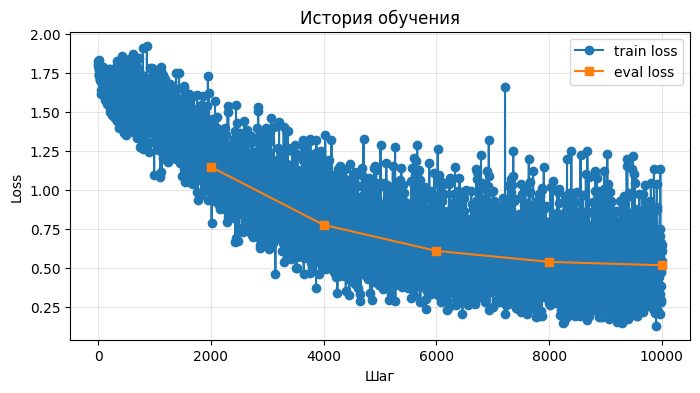

In [19]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("artifacts/training_curves.png")
plt.show()

Test metrics

In [20]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)
test_metrics = trainer.evaluate(tokenized_datasets["test"])
test_metrics

{'eval_loss': 0.4807683229446411,
 'eval_accuracy': 0.8555,
 'eval_f1_macro': 0.7778835335739168,
 'eval_f1_weighted': 0.852071491164283,
 'eval_runtime': 1.1794,
 'eval_samples_per_second': 1695.79,
 'eval_steps_per_second': 211.974,
 'epoch': 5.0}

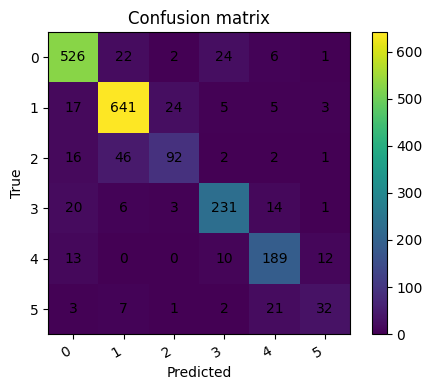

In [21]:
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids




cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()


In [22]:
pd.DataFrame({"text":emotion['test']['text'],"true_label":test_true,"pred_label":test_preds},columns=["text","true_label","pred_label"]).to_csv('artifacts/sample_predictions.csv')